# House Price Prediction Pipeline

This notebook builds and evaluates a machine learning pipeline for predicting house prices using a cleaned real estate dataset.

## Steps included

1. Load libraries and data
2. Split into train/test sets
3. Create custom transformers:
   - `TargetEncoder` for town-level target mean encoding
   - `FeatureEngineer` for date-based features
   - `DropColumns` for removing redundant columns
4. Assemble `sklearn.pipeline.Pipeline` with `XGBRegressor`
5. Train the model and evaluate using
   - mean squared error (MSE)
   - R² score
   - prediction error analysis
6. Save and reload the trained model with `pickle`
7. Generate a sample prediction

## Notes

- `cleaned_data.csv` is expected to contain preprocessed features and a `Price` target.
- Predicted price values are transformed back to real scale with `np.exp` where needed.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('/home/sukesh/Desktop/RealtyAI/B-13-RealtyAI-Smart-Real-Estate-Insight-Platform/dataset/cleaned_data.csv')

In [3]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mapping = None
        self.global_mean = None

    def fit(self, X, y):
        data = X.copy()
        data["Price"] = y
        
        self.mapping = data.groupby("Town/City")["Price"].mean()
        self.global_mean = y.mean()
        
        return self

    def transform(self, X):
        X = X.copy()
        
        X["Town_encoded"] = X["Town/City"].map(self.mapping)
        X["Town_encoded"] = X["Town_encoded"].fillna(self.global_mean)
        
        return X
    
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["Sale_time"] = X["Year"] * 12 + X["Month"]
        return X
    
class DropColumns(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[
            "Town/City", "District", "County",
            "Price_scaled", "Price_minmax"
        ], errors="ignore")

In [7]:
pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("target_encoding", TargetEncoder()),
    ("drop_columns", DropColumns()),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

In [8]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('target_encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None


In [9]:
y_pred = pipeline.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.14912965830869607
R2: 0.5620591296679281


In [10]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head()

,Actual Price,Predicted Price
75721,12.128117,11.231022
80184,11.112463,10.752698
19864,10.942014,10.541510
76699,11.277216,10.569616
92991,10.752591,10.715146


In [12]:
results["Actual Price Real"] = np.exp(results["Actual Price"])
results["Predicted Price Real"] = np.exp(results["Predicted Price"])

In [14]:
results["Error"] = results["Actual Price"] - results["Predicted Price"]
results["Absolute Error"] = results["Error"].abs()

results["Percentage Error"] = (
    results["Absolute Error"] / results["Actual Price"]
) * 100

In [15]:
print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
       Actual Price  Predicted Price  Actual Price Real  Predicted Price Real  \
75721     12.128117        11.231022           185001.0          75434.640625   
80184     11.112463        10.752698            67001.0          46756.003906   
19864     10.942014        10.541510            56501.0          37854.671875   
76699     11.277216        10.569616            79001.0          38933.734375   
92991     10.752591        10.715146            46751.0          45032.785156   
76434     10.373522        10.251734            32001.0          28331.621094   
84004     10.545368        10.808784            38001.0          49453.269531   
80917     10.126671        10.611532            25001.0          40600.363281   
60767     10.703267        10.914987            44501.0          54994.394531   
50074     10.976799        11.439968            58501.0          92964.046875   

          Error  Absolute Error  Percentage Error  
75721  0.897095        0.897095    

In [16]:
print("\nBest Predictions:")
print(results.sort_values("Absolute Error").head(5))

print("\nWorst Predicprint("\nBest Predictions:")
print(results.sort_values("Absolute Error").head(5))

print("\nWorst Predictions:")
print(results.sort_values("Absolute Error", ascending=False).head(5))tions:")
print(results.sort_values("Absolute Error", ascending=False).head(5))


Best Predictions:
       Actual Price  Predicted Price  Actual Price Real  Predicted Price Real  \
88710     10.292179        10.292205            29501.0          29501.748047   
19223     10.463132        10.463092            35001.0          34999.597656   
8580      10.896758        10.896712            54001.0          53998.535156   
2320      10.434145        10.434278            34001.0          34005.531250   
1978      10.968216        10.968388            58001.0          58010.980469   

          Error  Absolute Error  Percentage Error  
88710 -0.000025        0.000025          0.000247  
19223  0.000040        0.000040          0.000383  
8580   0.000046        0.000046          0.000418  
2320  -0.000133        0.000133          0.001277  
1978  -0.000172        0.000172          0.001569  

Worst Predictions:
       Actual Price  Predicted Price  Actual Price Real  Predicted Price Real  \
91454     14.375127        11.534669          1750001.0         102198.148438   


In [19]:
mae_real = mean_absolute_error(
    results["Actual Price"],
    results["Predicted Price"]
)

print("\nMAE (Real Price):", mae_real)


MAE (Real Price): 0.27862612023422056


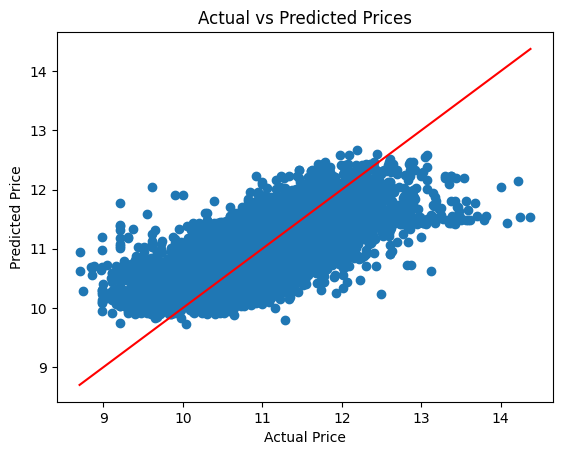

In [23]:
plt.scatter(results["Actual Price"], results["Predicted Price"])
plt.plot(
    [results["Actual Price"].min(), results["Actual Price"].max()],
    [results["Actual Price"].min(), results["Actual Price"].max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [24]:
with open("house_price_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [25]:
with open("house_price_pipeline.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [26]:
test_pred = loaded_model.predict(X_test.head(1))
test_pred_real = np.exp(test_pred)

print("\nSample Prediction (Real Price):", test_pred_real)


Sample Prediction (Real Price): [75434.64]
